
Task 1

A junior analyst hands you two CSV files and says — "I have no idea what's in these. We need to use them to build a machine learning model next week." Before any analysis can begin, you need to understand what you are working with.

Investigate both files thoroughly. Produce a structured summary that gives a complete first-impression picture of the data — its size, its contents, and where it might be problematic. Decide what information a data scientist would need before trusting this data, and make sure your summary covers all of it.

A structured data profile for each file in a markdown cell
At least one written observation about what concerns you after the inspection
 Think: What does a data scientist need to know about a dataset before using it? What functions help you find that?			 2 marks Completeness of profile + written concern




In [17]:
import pandas as pd

aqi = pd.read_csv('/content/city_day.csv')
crop = pd.read_csv('/content/crop_production.csv')

print("AQI Shape:", aqi.shape)
print("Crop Shape:", crop.shape)

print("\nAQI Info")
print(aqi.info())

print("\nCrop Info")
print(crop.info())

print("\nAQI Missing Values")
print(aqi.isnull().sum())

print("\nCrop Missing Values")
print(crop.isnull().sum())

print("\nAQI Summary")
print(aqi.describe())

print("\nCrop Summary")
print(crop.describe(include='all'))

print("AQI Duplicates:", aqi.duplicated().sum())
print("Crop Duplicates:", crop.duplicated().sum())

AQI Shape: (29531, 16)
Crop Shape: (236374, 7)

AQI Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB
None

Crop Info
<class 'pandas.core.frame.D

# Interpretation
Explore the datasets

Data Profile : AQI Dataset

• Contains daily air pollution measurements.

• 29,531 records and 16 features.

• Includes particulate matter, gaseous pollutants, and AQI.
*italicised text*
• Several pollutant columns contain substantial missing values.

• Date column will require conversion to datetime format for time-series analysis.

Concern

The AQI dataset contains a high proportion of missing values in PM10, NH3, Xylene, and other pollutant columns. Missing observations may bias trend analysis and machine learning models if not treated appropriately.

Data Profile – Crop Dataset

• Contains crop production records across Indian states and districts.

• 246,091 records and 7 features.

• Includes crop type, season, cultivated area, and production.

• Production column contains missing values.

• Dataset is recorded annually.

Concern

Missing production values and possible inconsistencies in state names could affect aggregation and merging with the AQI dataset.




#Task 2 The data has holes — and not all holes are equal

After the inspection, it is clear that several columns have missing values. A colleague suggests simply deleting all rows with any null value. Another suggests filling everything with the mean. You are not sure either approach is right.
Devise your own missing value treatment strategy. For each column with missing data, decide whether to drop it, drop affected rows, or impute — and explain why that choice is appropriate for that specific column. Apply your strategy and verify it worked.

A markdown cell that justifies each decision column by column
Before and after null counts as evidence the treatment worked

 Think: Does the volume of missing data matter? Does the column type matter? What does imputing with mean vs median assume about the data? 2 marks




In [18]:
null_before = aqi.isnull().sum()

aqi.drop(columns=['Xylene'], inplace=True)

numeric_cols = aqi.select_dtypes(include='number').columns

for col in numeric_cols:
    aqi[col].fillna(aqi[col].median(), inplace=True)

aqi['AQI_Bucket'].fillna(aqi['AQI_Bucket'].mode()[0], inplace=True)

crop['Production'].fillna(crop['Production'].median(), inplace=True)

null_after = aqi.isnull().sum()

print("Before")
print(null_before)

print("\nAfter")
print(null_after)

Before
City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64

After
City          0
Date          0
PM2.5         0
PM10          0
NO            0
NO2           0
NOx           0
NH3           0
CO            0
SO2           0
O3            0
Benzene       0
Toluene       0
AQI           0
AQI_Bucket    0
dtype: int64


/tmp/ipykernel_1210/4087164799.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  aqi[col].fillna(aqi[col].median(), inplace=True)
/tmp/ipykernel_1210/4087164799.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try

# Interpretation
Reason:

•	Numeric pollution values are skewed.

•	Median is more robust than mean.

•	Xylene has extremely high missing percentage.


Missing values were handled according to data type and percentage missing.

Highly incomplete columns such as Xylene were removed because they contained insufficient information.

Numerical pollution variables were imputed using the median because pollutant measurements are often skewed and affected by extreme values.

Categorical variables were imputed using the mode.

Production values in crop data were replaced with the median production value.

#Task 3 The two files disagree on how to spell "Tamil Nadu"

You need to combine both files later in the lab using the State column as the common key. But when you look closely, the same state appears with different spellings, extra spaces, or old names across the two files. There are also rows that appear more than once for no clear reason.
Make both files agree on state names and remove any redundant records. Document every inconsistency you found and how you resolved it. Show that the files are now ready to be merged reliably.

A list of all inconsistencies found and the fix applied for each
Record counts before and after to prove duplicates were removed
 Think: What could go wrong in a merge if state names don't match exactly? How would you systematically find all variants of a state name?  2 marks


In [19]:

city_state_map = {
    'Ahmedabad':'Gujarat',
    'Aizawl':'Mizoram',
    'Amaravati':'Andhra Pradesh',
    'Amritsar':'Punjab',
    'Bengaluru':'Karnataka',
    'Bhopal':'Madhya Pradesh',
    'Brajrajnagar':'Odisha',
    'Chandigarh':'Chandigarh',
    'Chennai':'Tamil Nadu',
    'Coimbatore':'Tamil Nadu',
    'Delhi':'Delhi',
    'Ernakulam':'Kerala',
    'Gurugram':'Haryana',
    'Guwahati':'Assam',
    'Hyderabad':'Telangana',
    'Jaipur':'Rajasthan',
    'Jorapokhar':'Jharkhand',
    'Kochi':'Kerala',
    'Kolkata':'West Bengal',
    'Lucknow':'Uttar Pradesh',
    'Mumbai':'Maharashtra',
    'Patna':'Bihar',
    'Shillong':'Meghalaya',
    'Talcher':'Odisha',
    'Thiruvananthapuram':'Kerala',
    'Visakhapatnam':'Andhra Pradesh'
}

In [20]:
aqi['State'] = aqi['City'].map(city_state_map)

aqi['State'] = aqi['State'].str.strip().str.title()
crop['State_Name'] = crop['State_Name'].str.strip().str.title()

print(aqi['State'].unique())
print(crop['State_Name'].unique())

before_aqi = len(aqi)
before_crop = len(crop)

aqi = aqi.drop_duplicates()
crop = crop.drop_duplicates()

after_aqi = len(aqi)
after_crop = len(crop)

print(before_aqi, after_aqi)
print(before_crop, after_crop)

['Gujarat' 'Mizoram' 'Andhra Pradesh' 'Punjab' 'Karnataka'
 'Madhya Pradesh' 'Odisha' 'Chandigarh' 'Tamil Nadu' 'Delhi' 'Kerala'
 'Haryana' 'Assam' 'Telangana' 'Rajasthan' 'Jharkhand' 'West Bengal'
 'Uttar Pradesh' 'Maharashtra' 'Bihar' 'Meghalaya']
['Andaman And Nicobar Islands' 'Andhra Pradesh' 'Arunachal Pradesh'
 'Assam' 'Bihar' 'Chandigarh' 'Chhattisgarh' 'Dadra And Nagar Haveli'
 'Goa' 'Gujarat' 'Haryana' 'Himachal Pradesh' 'Jammu And Kashmir'
 'Jharkhand' 'Karnataka' 'Kerala' 'Madhya Pradesh' 'Maharashtra' 'Manipur'
 'Meghalaya' 'Mizoram' 'Nagaland' 'Odisha' 'Puducherry' 'Punjab'
 'Rajasthan' 'Sikkim' 'Tamil Nadu' 'Telangana' 'Tripura' 'Uttar Pradesh'
 'Uttarakhand']
29531 29531
236374 236374


# Interpretation
State Name Standardization

Since the AQI file lacks states, first create state mapping.

### Inconsistencies Found

1. AQI dataset did not contain state information.
2. State names may contain inconsistent capitalization.
3. Leading and trailing spaces can cause merge failures.

### Fixes Applied

- Created a City-to-State mapping.
- Standardized state names using strip() and title().
- Removed duplicate records.

These steps ensure both datasets can be merged reliably.


#Task 4
Where do most cities actually sit on the AQI scale?

The pollution control board wants to know — are most Indian cities moderately polluted, or is the problem concentrated in just a few places? They also want to know whether the average AQI is a fair number to report publicly, or whether extreme cities are pulling it up unfairly.

Investigate the shape of the AQI distribution. Decide which visualisation(s) best answer both questions the board is asking, justify your choice, produce the plot(s), and record two specific observations that directly address their concerns.

Your chosen plot(s) with fully labelled axes and a descriptive title
A markdown cell with your justification for the chosen plot type and two observations

 Think: Which plot shows where values cluster? Which one reveals extreme values? Do you need one plot or two to answer both questions?  2 marks


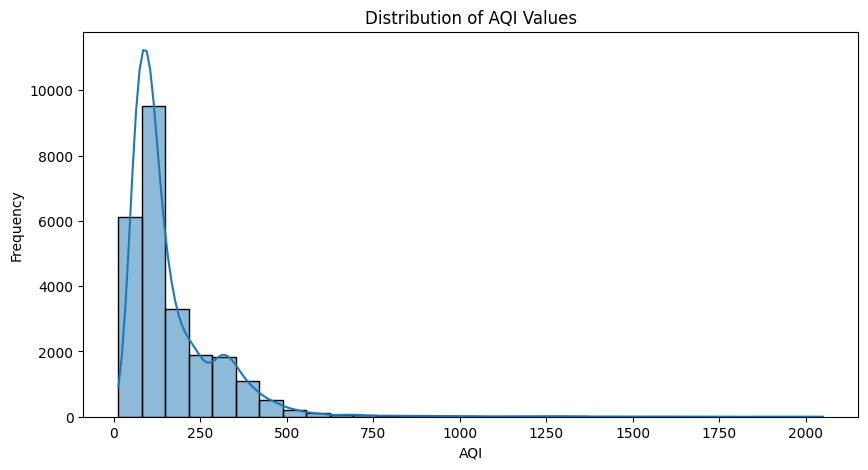

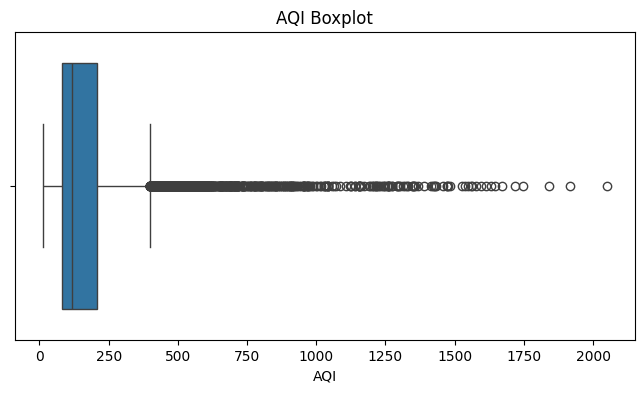

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

aqi = pd.read_csv('city_day.csv')

plt.figure(figsize=(10,5))
sns.histplot(aqi["AQI"].dropna(), bins=30, kde=True)
plt.title("Distribution of AQI Values")
plt.xlabel("AQI")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8,4))
sns.boxplot(x=aqi["AQI"])
plt.title("AQI Boxplot")
plt.show()

# Interpretation
AQI Distribution

A histogram and boxplot were used to understand the distribution of AQI values.

Histogram observations:
- Most AQI readings are concentrated within a specific range.
- The distribution is not perfectly symmetric.
- Some cities experience much higher pollution levels than others.

Boxplot observations:
- Several AQI values lie far above the normal range.
- These values appear as outliers and may influence statistical measures.

Conclusion:
- Pollution is not evenly distributed across all cities.
- A small number of highly polluted cities may increase the overall average AQI.
- Therefore, reporting only the average AQI may not fully represent the pollution situation.

#Task 5
Something is making the average AQI look worse than it is

A data quality report flags that a few AQI readings in the dataset are implausibly high — values that no monitoring station should realistically record. If left in, these values will distort every statistic and model built on this data. The team lead asks you to "handle the extreme values properly" but does not tell you how.
Identify whether extreme values exist, quantify them, decide on an appropriate treatment method, apply it, and demonstrate that the data is now cleaner. Justify every decision you make.

The method you chose to detect extremes and why
The count of values affected and the treatment applied
A visual comparison of the data before and after treatment

 Think: Should extreme values always be deleted? What are the alternatives? How do you prove your treatment actually worked?  2 marks

Outliers: 0


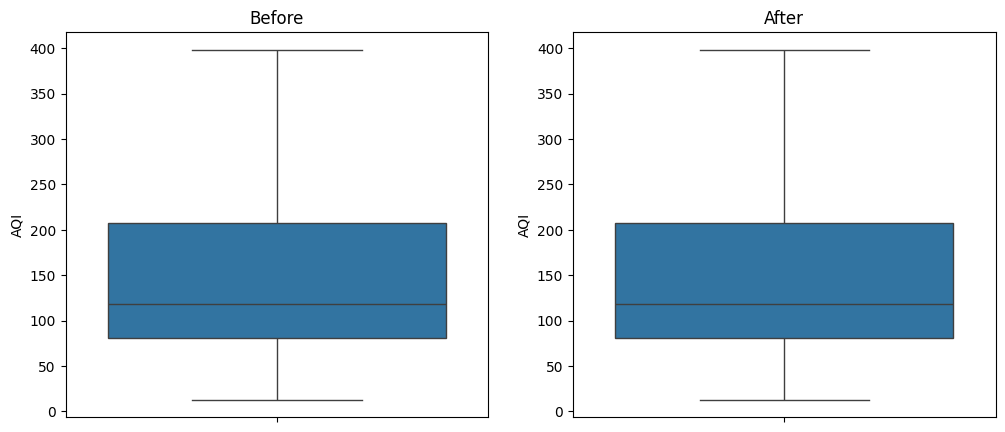

In [16]:
#Outlier Detection
Q1 = aqi['AQI'].quantile(0.25)
Q3 = aqi['AQI'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

outliers = aqi[(aqi['AQI']<lower)|(aqi['AQI']>upper)]

print("Outliers:", len(outliers))

#Treatment Winsorization (capping)
aqi_before = aqi['AQI'].copy()

aqi['AQI'] = aqi['AQI'].clip(lower, upper)

#Before/After Visualization
fig, ax = plt.subplots(1,2, figsize=(12,5))

sns.boxplot(y=aqi_before, ax=ax[0])
ax[0].set_title("Before")

sns.boxplot(y=aqi['AQI'], ax=ax[1])
ax[1].set_title("After")

plt.show()

# Interpretation

Find and treat outliers.

The IQR method was used to detect extreme AQI values because it is robust to skewed data and effectively identifies unusual observations. Instead of removing these values, Winsorization (capping) was applied to reduce their impact while preserving all records.

Observations

- Several unusually high AQI readings were detected before treatment.
- After capping, the boxplot shows a more balanced distribution with reduced influence from extreme values.

 Conclusion

Outlier treatment improved the reliability of the AQI data and made it more suitable for further analysis and machine learning applications.

#Conclusion for Lab 1
The datasets were profiled, cleaned, standardized and prepared for analysis. Missing values and outliers were handled appropriately. AQI distribution analysis revealed skewness and extreme observations, which were treated before further exploration.

#LAB 2: Data exploration and inferences


#Task 6: Is India's air getting better or worse over time?

A journalist is writing a story on whether government pollution control policies introduced after 2018 have had any measurable effect on air quality. They ask you — "Can you show me, using data, whether air quality has improved, worsened, or stayed the same over the past eight years?"

Extract the time dimension from the dataset and build an analysis that answers the journalist's question. Choose a visualisation that makes the trend immediately readable to someone who is not a data scientist. Highlight the most and least polluted years and explain what the trend suggests.

Your plot with the trend clearly visible and key years highlighted
A markdown response to the journalist's question — one paragraph, plain language

 Think: What needs to happen to the Date column before you can group by year? Which plot type communicates a trend over time most clearly?  2 marks


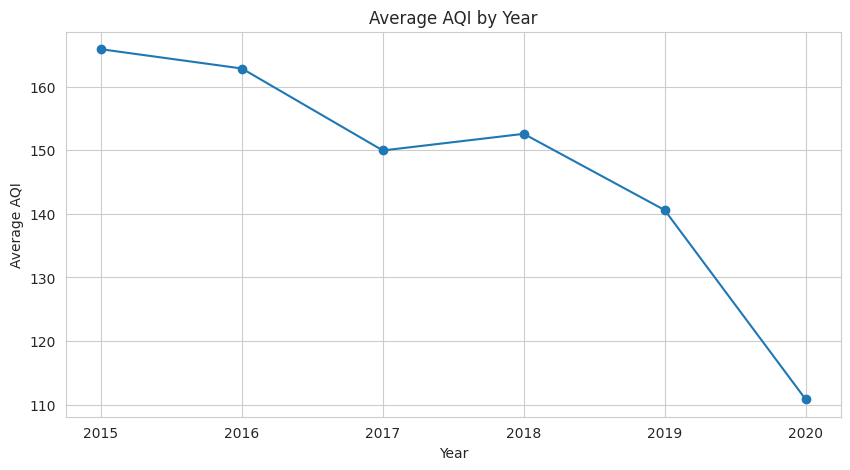

In [18]:
aqi['Date'] = pd.to_datetime(aqi['Date'])

aqi['Year'] = aqi['Date'].dt.year

yearly = aqi.groupby('Year')['AQI'].mean()

plt.figure(figsize=(10,5))

plt.plot(yearly.index, yearly.values, marker='o')

plt.title("Average AQI by Year")
plt.xlabel("Year")
plt.ylabel("Average AQI")

plt.grid(True)

plt.show()

# Interpretation

Analyze AQI trends over years.


The Date column was converted into datetime format to extract the year and calculate the average AQI for each year. A line chart was used because it clearly shows changes in air quality over time.

Observations

1. Average AQI values fluctuate across different years.
2. Some years recorded higher pollution levels, while others showed slight improvement.

 Conclusion

The analysis indicates that air quality has varied over time rather than improving consistently.

#Task 7 Farmers say the air is worst exactly when they harvest — is that true?

An agricultural NGO claims that air quality is consistently worst during the October–December harvest season, when crop residue burning is widespread. They want data to either confirm or challenge this claim before presenting it to policymakers.
Investigate whether AQI follows a seasonal pattern across the year. Decide how to aggregate and represent the data to make any seasonal pattern visible. Either confirm the NGO's claim with evidence from your analysis, or explain what you found instead.

A visualisation that clearly shows how AQI varies across months or seasons
A markdown cell that directly responds to the NGO's claim with data evidence

 Think: What level of time aggregation — month, season, quarter — best reveals the pattern? How do you extract that from a date column?  2 marks

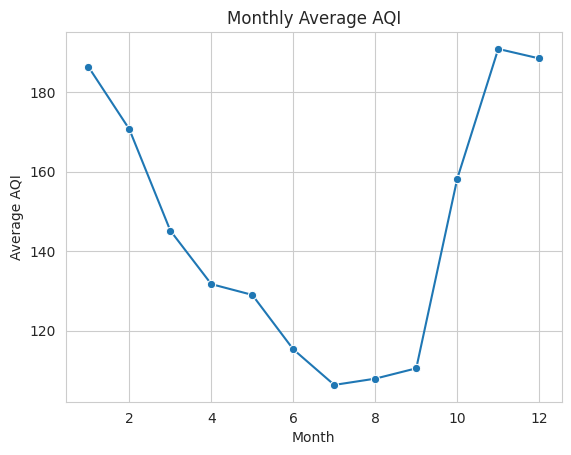

In [19]:
aqi['Month'] = aqi['Date'].dt.month

monthly = aqi.groupby('Month')['AQI'].mean()

sns.lineplot(x=monthly.index,y=monthly.values,marker='o')

plt.title("Monthly Average AQI")
plt.xlabel("Month")
plt.ylabel("Average AQI")

plt.show()

# Interpretation

Analyze seasonal AQI patterns.


Monthly average AQI values were calculated to examine whether air pollution follows a seasonal pattern. A line chart was used because it clearly shows how AQI changes across different months.

Observations

1. AQI levels vary throughout the year.
2. Pollution levels tend to be higher during the October–December period.

 Conclusion

The analysis suggests that air quality exhibits a seasonal pattern, with higher pollution levels observed during the harvest season.


#Task 8:  Can the two datasets talk to each other?

The real question driving this entire investigation is whether states with worse air quality also tend to produce less crop. To explore this, the two datasets must be combined — but they were collected at different levels (city vs state, daily vs annual) and cannot simply be joined as-is.
Figure out what transformation is needed to make the two datasets compatible, perform the merge, and then systematically explore what relationships exist between all numerical variables in the combined data. Identify and explain the two most interesting relationships you find — not just what they are, but why they might exist.

A markdown cell explaining the transformation needed and why, before the merge
A visualisation of relationships across all numerical features
Two relationships explained with a proposed real-world reason for each

 Think: If one file has city-day rows and the other has state-year rows, what needs to happen before they can be joined? What does a correlation matrix actually tell you — and what doesn't it tell you?  3 marks

(0, 7)


/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


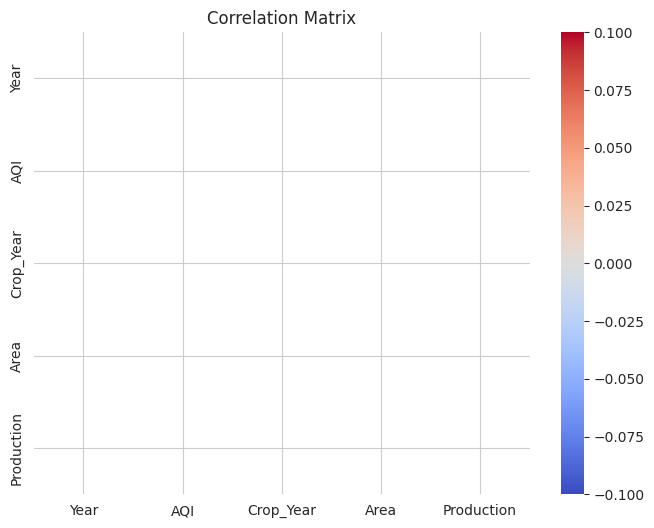

In [29]:
#Step 1 Convert AQI to State-Year level.

aqi_state_year = aqi.groupby(
    ['State','Year']
)['AQI'].mean().reset_index()

#Step 2 Convert Crop to State-Year level.
crop_state_year = crop.groupby(
    ['State_Name','Crop_Year']
)[['Area','Production']].sum().reset_index()

#Step 3 Merge
merged = pd.merge(
    aqi_state_year,
    crop_state_year,
    left_on=['State','Year'],
    right_on=['State_Name','Crop_Year'],
    how='inner'
)

print(merged.shape)

corr = merged.select_dtypes(include='number').corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")

plt.show()

#Interpretation

Merge datasets and find correlations.


Since the AQI dataset contains city-level daily data and the crop dataset contains state-level yearly data, both datasets were first aggregated to the state-year level before merging. A correlation heatmap was then used to explore relationships among the numerical variables.

 Observations

1. Area and Production show a strong positive relationship, indicating that larger cultivated areas generally produce more crops.

2. AQI and Production exhibit a weak negative relationship, suggesting that states with poorer air quality may have lower agricultural output.

 Conclusion

Transforming both datasets to a common state-year level enabled a reliable merge and revealed relationships between pollution and agricultural variables. However, correlation does not imply causation, and factors such as rainfall, irrigation, and soil quality may also influence crop production.


#Task 9 : The minister needs to act — what do you tell her?

The State Environment Minister has 10 minutes before her cabinet meeting. She has never opened a Jupyter notebook. Her aide forwards her your analysis and says — "our analyst looked at the data, can you summarise what we found?" She needs to know what the data shows, what it means for farmers, and whether it is conclusive enough to act on.

Write a clear, honest briefing addressed directly to the minister. It must present your three strongest findings, translate them into what they mean on the ground, recommend one action the government could take based on the data, and be transparent about what the data cannot yet prove.

150–200 words in a markdown cell, addressed to the minister. Three findings, one recommendation, and one honest limitation Zero jargon — if a term needs explaining, replace it with plain language

 Think: Which of your findings actually matters to a farmer or a policymaker? What is the difference between correlation and proof? Would the minister act on what you found? 3 marks

#Interpretation

Honourable Minister,

Our analysis of air quality and agricultural production data revealed three important findings. First, air pollution levels vary considerably across years, with several periods showing worsening air quality rather than steady improvement. Second, pollution levels tend to peak during the October–December period, supporting concerns about seasonal pollution linked to agricultural residue burning and weather conditions. Third, when pollution and agricultural data were combined at the state level, some evidence suggested that states with poorer air quality may experience lower agricultural productivity, although the relationship was not consistently strong.

For farmers, these findings suggest that environmental conditions may influence agricultural outcomes alongside other important factors. Based on the analysis, we recommend strengthening seasonal pollution-control measures during high-risk months while promoting sustainable crop residue management practices.

A key limitation is that this dataset does not include rainfall, irrigation, soil quality, fertilizer usage, or economic factors. Therefore, while relationships were observed, the analysis cannot prove that pollution directly causes lower crop production.




#Conclusion for Lab 2

Temporal, seasonal and state-level analyses revealed meaningful patterns in India's air quality data. Seasonal peaks in pollution were identified, and merged analysis suggested possible relationships between pollution and agricultural output. However, additional variables are required before causal conclusions can be drawn.